# Report Figures

Generates the four figures embedded in `report.pdf`, from the outputs of `04_cleaning.ipynb`, `05_skill_extraction.ipynb`, and `06_recommendation_engine.ipynb`. Saves PNGs to `figures/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

BASE = "./"
OUT = "./figures/"
os.makedirs(OUT, exist_ok=True)

ACCENT = "#1F6F63"
FLAG = "#B5690E"
NEUTRAL = "#5B665F"

postings = pd.read_parquet(f"{BASE}postings_clean.parquet")
extracted = pd.read_parquet(f"{BASE}job_skills_extracted.parquet")
print(f"postings: {postings.shape}, extracted: {extracted.shape}")

postings: (123849, 32), extracted: (383288, 3)


## Figure 1: Missingness by column

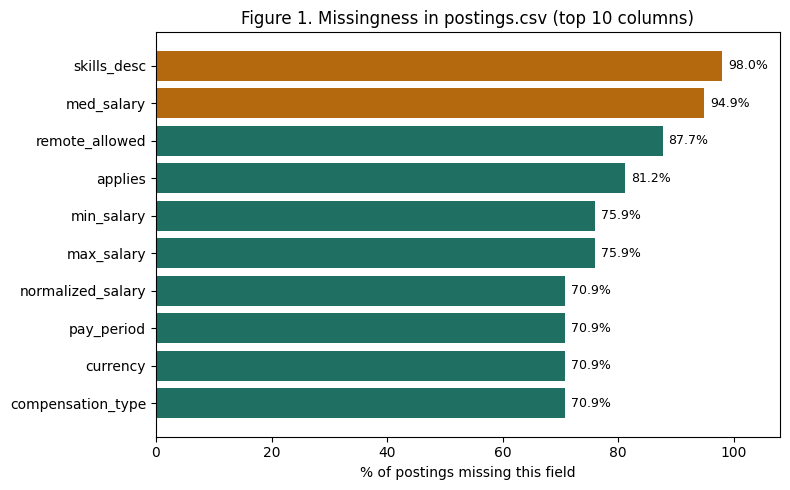

In [2]:
missing = (postings.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0].head(10)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [FLAG if v >= 90 else ACCENT for v in missing.values]
ax.barh(missing.index[::-1], missing.values[::-1], color=colors[::-1])
ax.set_xlabel("% of postings missing this field")
ax.set_title("Figure 1. Missingness in postings.csv (top 10 columns)")
for i, v in enumerate(missing.values[::-1]):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, 108)
plt.tight_layout()
plt.savefig(f"{OUT}fig1_missingness.png", dpi=150)
plt.show()

## Figure 2: Top extracted skills by category

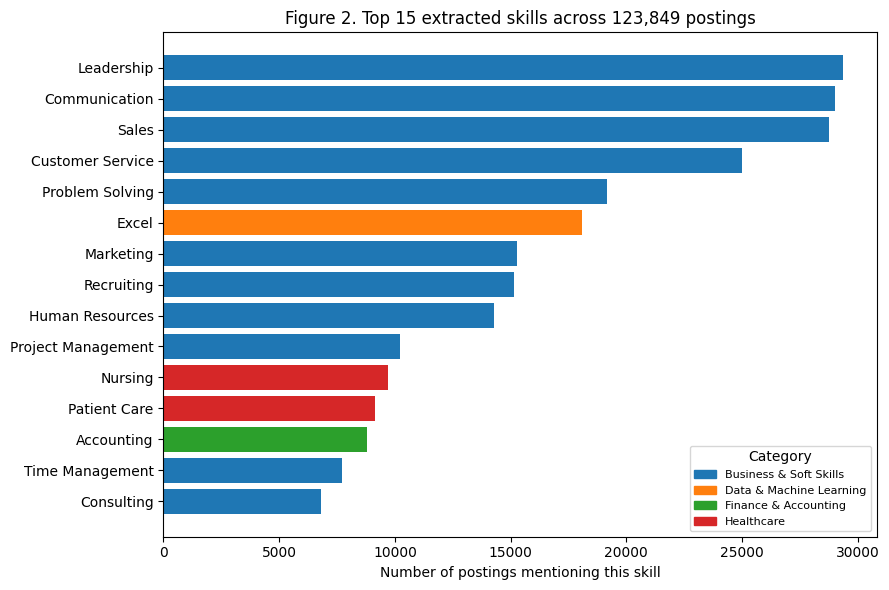

In [3]:
top_skills = extracted["skill"].value_counts().head(15)
cat_map = extracted.drop_duplicates("skill").set_index("skill")["category"]
categories = top_skills.index.map(cat_map)
unique_cats = sorted(set(categories))
cmap = plt.get_cmap("tab10")
cat_colors = {c: cmap(i % 10) for i, c in enumerate(unique_cats)}
bar_colors = [cat_colors[c] for c in categories]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_skills.index[::-1], top_skills.values[::-1], color=bar_colors[::-1])
ax.set_xlabel("Number of postings mentioning this skill")
ax.set_title("Figure 2. Top 15 extracted skills across 123,849 postings")
handles = [Patch(color=cat_colors[c], label=c) for c in unique_cats if c in categories.tolist()]
ax.legend(handles=handles, loc="lower right", fontsize=8, title="Category")
plt.tight_layout()
plt.savefig(f"{OUT}fig2_top_skills.png", dpi=150)
plt.show()

## Figure 3: USD salary distribution

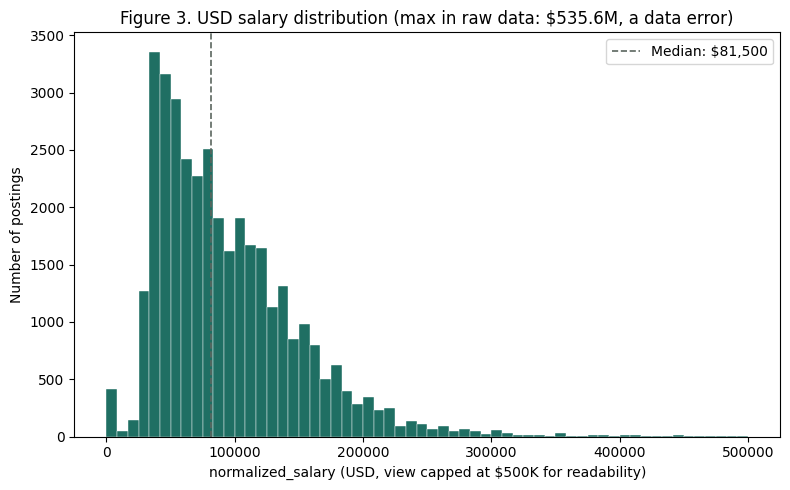

In [4]:
usd = postings[postings["currency"] == "USD"]["normalized_salary"].dropna()
usd_reasonable = usd[usd.between(0, 500_000)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(usd_reasonable, bins=60, color=ACCENT, edgecolor="white", linewidth=0.3)
ax.axvline(usd.median(), color=NEUTRAL, linestyle="--", linewidth=1.2, label=f"Median: ${usd.median():,.0f}")
ax.set_xlabel("normalized_salary (USD, view capped at $500K for readability)")
ax.set_ylabel("Number of postings")
ax.set_title("Figure 3. USD salary distribution (max in raw data: $535.6M, a data error)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}fig3_salary_distribution.png", dpi=150)
plt.show()

## Figure 4: Recommendation engine lift over a random baseline

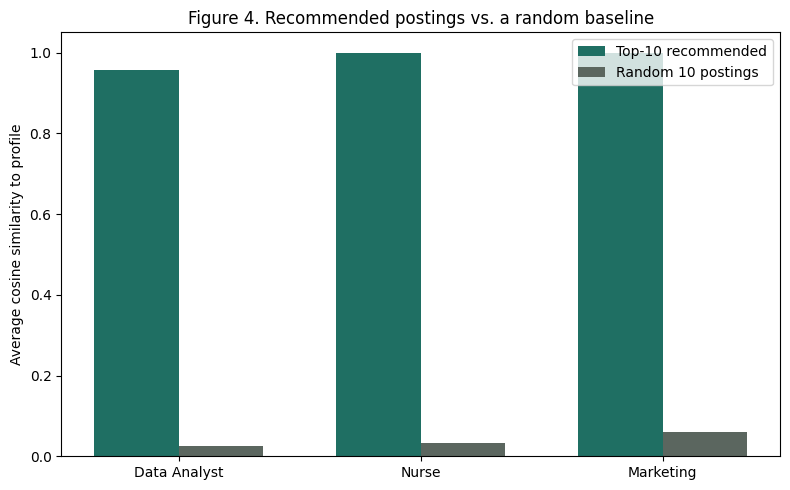

In [5]:
artifacts = np.load(f"{BASE}recommendation_artifacts.npz", allow_pickle=True)
weighted_matrix = artifacts["weighted_matrix"]
idf = artifacts["idf"]
matrix_norms = artifacts["matrix_norms"]
skill_list = list(artifacts["skill_list"])
skill_to_idx = {s: i for i, s in enumerate(skill_list)}
n_skills = len(skill_list)
n_jobs = weighted_matrix.shape[0]

def recommend(user_skills, top_n=10):
    user_vec = np.zeros(n_skills, dtype=np.float32)
    for s in user_skills:
        if s in skill_to_idx:
            user_vec[skill_to_idx[s]] = 1.0
    user_weighted = user_vec * idf
    user_norm = np.linalg.norm(user_weighted)
    scores = weighted_matrix @ user_weighted
    denom = matrix_norms * user_norm
    denom[denom == 0] = 1
    cosine = scores / denom
    top_idx = np.argsort(-cosine)[:top_n]
    return cosine[top_idx], user_weighted, user_norm

rng = np.random.default_rng(42)
test_profiles = {
    "Data Analyst": ["Python", "SQL", "Excel", "Data Analysis"],
    "Nurse": ["Nursing", "Patient Care", "HIPAA"],
    "Marketing": ["Marketing", "Digital Marketing", "SEO"],
}

profile_names, top10_avgs, random_avgs = [], [], []
for name, skills in test_profiles.items():
    top_scores, user_weighted, user_norm = recommend(skills, top_n=10)
    random_idx = rng.choice(n_jobs, size=10, replace=False)
    random_scores = weighted_matrix[random_idx] @ user_weighted
    random_norms = matrix_norms[random_idx] * user_norm
    random_norms[random_norms == 0] = 1
    random_sim = (random_scores / random_norms).mean()
    profile_names.append(name)
    top10_avgs.append(top_scores.mean())
    random_avgs.append(random_sim)

x = np.arange(len(profile_names))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, top10_avgs, width, label="Top-10 recommended", color=ACCENT)
ax.bar(x + width/2, random_avgs, width, label="Random 10 postings", color=NEUTRAL)
ax.set_xticks(x)
ax.set_xticklabels(profile_names)
ax.set_ylabel("Average cosine similarity to profile")
ax.set_title("Figure 4. Recommended postings vs. a random baseline")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}fig4_recommendation_lift.png", dpi=150)
plt.show()

## Figure 5: How AI fit into the development workflow

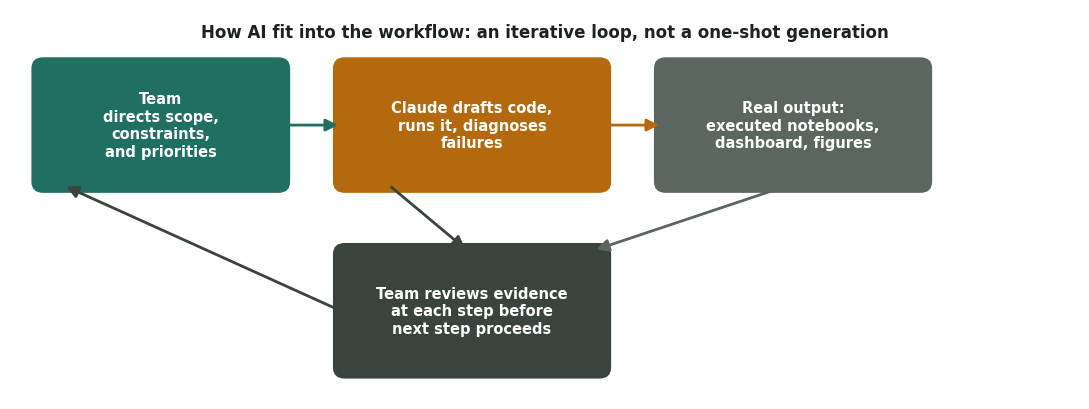

In [6]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

TEAL_HEX, FLAG_HEX, NEUTRAL_HEX = "#1F6F63", "#B5690E", "#5B665F"

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4.2)
ax.axis("off")

def box(x, y, w, h, text, color, fontsize=10.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08,rounding_size=0.12",
                                 linewidth=0, facecolor=color))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", color="white",
            fontsize=fontsize, fontweight="bold")

def arrow(x1, y1, x2, y2, color):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=18,
                                  linewidth=2, color=color, shrinkA=2, shrinkB=2))

box(0.3, 2.3, 2.5, 1.3, "Team\ndirects scope,\nconstraints,\nand priorities", TEAL_HEX)
box(3.4, 2.3, 2.7, 1.3, "Claude drafts code,\nruns it, diagnoses\nfailures", FLAG_HEX)
box(6.7, 2.3, 2.7, 1.3, "Real output:\nexecuted notebooks,\ndashboard, figures", NEUTRAL_HEX)
box(3.4, 0.3, 2.7, 1.3, "Team reviews evidence\nat each step before\nnext step proceeds", "#3A443C")

arrow(2.8, 2.95, 3.4, 2.95, TEAL_HEX)
arrow(6.1, 2.95, 6.7, 2.95, FLAG_HEX)
arrow(3.9, 2.3, 4.7, 1.6, "#3A443C")
arrow(8.0, 2.3, 6.0, 1.6, NEUTRAL_HEX)
arrow(3.4, 0.95, 0.55, 2.3, "#3A443C")

ax.text(5.5, 3.9, "How AI fit into the workflow: an iterative loop, not a one-shot generation",
        ha="center", fontsize=12, fontweight="bold", color="#1B2320")

plt.tight_layout()
plt.savefig(f"{OUT}fig5_ai_workflow.png", dpi=150, facecolor="white")
plt.show()